## Setup

Set real_time to false if you want to read from file

In [17]:
import serial
import csv
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.special import gammaincc
from scipy.stats import norm
import numpy.fft as fft

PORT = "COM8"
BAUD = 230400

load_from_file = False
load_file_path = Path("data/06_25_2026/run_15_13_02.csv")
sensors = ['BPW34_1', 'BPW34_2', 'Inano_1', 'Inano_2']

adc_max = 16383
v_ref = 5
SAMPLES_PER_PACKET = 50
payload_dtype = np.dtype([
    ('timestamp', '<u4'),
    ('BPW34_1', '<u2'),
    ('BPW34_2', '<u2'),
    ('Inano_1', '<u2'),
    ('Inano_2', '<u2')
])



BYTES_PER_SAMPLE = payload_dtype.itemsize * SAMPLES_PER_PACKET




## Saves realtime data to file


In [ ]:
ser = serial.Serial(PORT, BAUD, timeout=1)
NUM_SAMPLES_TO_SAVE = 1000   # set to None to run until interrupted

now = datetime.now()
savefile_path = Path(f"data/{now.strftime('%m_%d_%Y')}/run_{now.strftime('%H_%M_%S')}.csv")
savefile_path.parent.mkdir(parents=True, exist_ok=True)

header_written = False
sample_count = 0


##read packets of data from the serial port and save it to a CSV file
try:
    while NUM_SAMPLES_TO_SAVE is None or sample_count < NUM_SAMPLES_TO_SAVE:
        if ser.read(1) == b'\xAA' and ser.read(1) == b'\xBB':
            raw_data = ser.read(BYTES_PER_SAMPLE) 
            if len(raw_data) == BYTES_PER_SAMPLE:
                data = np.frombuffer(raw_data, dtype=payload_dtype)
                mean_delta_us = np.mean(np.diff(data['timestamp']))
                if mean_delta_us > 0:
                    sampling_rate = 1.0 / (mean_delta_us * 1e-6)
                    # write all samples in this packet to file
                    df = pd.DataFrame(data)
                    df.to_csv(savefile_path, mode='a', header=not header_written, index=False)
                    header_written = True
                    sample_count += SAMPLES_PER_PACKET
                else:
                    print("Timestamps did not change")
except KeyboardInterrupt:
    print("Stopping...")
finally:
    ser.close()
    print(f"Saved {sample_count} samples to {savefile_path}")

Saved 1000 samples to data\06_25_2026\run_15_19_36.csv


## Realtime plot

Reads packets from the Arduino and updates a scrolling view of the four ADC channels

In [19]:
import pyqtgraph as pg
from pyqtgraph.Qt import QtCore

ser = serial.Serial(PORT, BAUD, timeout=1)
channels = ['BPW34_1', 'BPW34_2', 'Inano_1', 'Inano_2']
N = 2000
buffers = {ch: np.zeros(N) for ch in channels}

app = pg.mkQApp("QRNG realtime")
win = pg.GraphicsLayoutWidget(show=True, title="QRNG realtime")
curves = {}
for i, ch in enumerate(channels):
    p = win.ci.addPlot(row=i, col=0, title=ch)
    p.setLabel('left', 'mV')
    curves[ch] = p.plot()


def update():
    if ser.read(1) == b'\xAA' and ser.read(1) == b'\xBB':
        raw = ser.read(BYTES_PER_SAMPLE)
        if len(raw) == BYTES_PER_SAMPLE:
            data = np.frombuffer(raw, dtype=payload_dtype)
            for ch in channels:
                buffers[ch] = np.roll(buffers[ch], -SAMPLES_PER_PACKET)
                buffers[ch][-SAMPLES_PER_PACKET:] = (data[ch] / adc_max * v_ref)*1000 ##from v to mV
                curves[ch].setData(buffers[ch])

timer = QtCore.QTimer()
timer.timeout.connect(update)
timer.start()
pg.exec()
ser.close()

## Spectrogram Plotting

Make sure to specify load_from_file in the setup block to load from file instead of read real time data

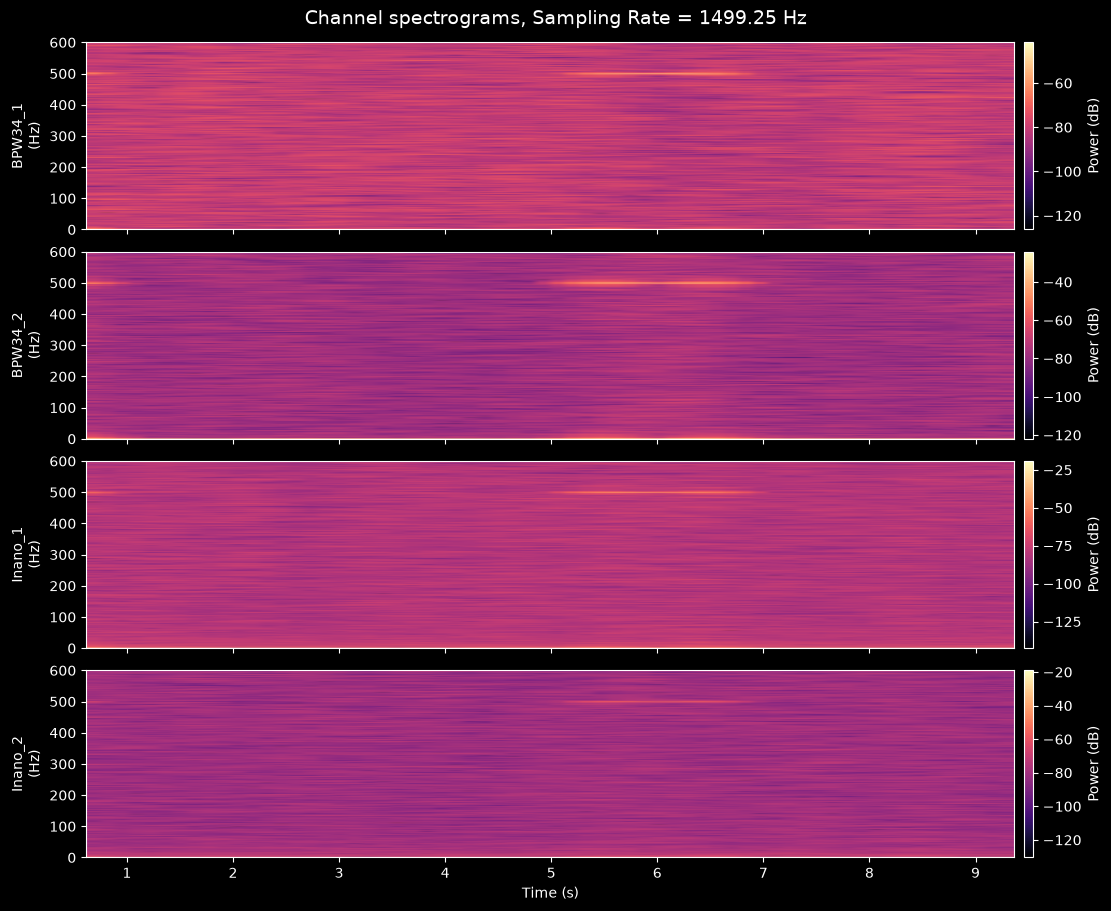

In [35]:
from scipy.signal import get_window

ser = serial.Serial(PORT, BAUD, timeout=1)
NFFT = 4096        
WINDOWSIZE = 2048
WINDOW = 'hamming'
OVERLAP = 90 
BAND = [340, 360]  # bandpass filter range in Hz
FILTER = False

## load from file or read from serial
## after this block: samples[ch] and times are plain 1-D numpy arrays
if load_from_file:
    df = pd.read_csv(load_file_path, index_col='timestamp')
    samples = {ch: df[ch].to_numpy() / adc_max * v_ref for ch in sensors}
    times = df.index.to_numpy()
else:
    sample_chunks = {ch: [] for ch in sensors}
    time_chunks = []
    start = time.time()
    while time.time() - start < 10:
        if ser.read(1) == b'\xAA' and ser.read(1) == b'\xBB':
            raw = ser.read(BYTES_PER_SAMPLE)
            if len(raw) == BYTES_PER_SAMPLE:
                data = np.frombuffer(raw, dtype=payload_dtype)
                time_chunks.append(data['timestamp'])
                for ch in sensors:
                    sample_chunks[ch].append(data[ch] / adc_max * v_ref)
    ser.close()
    samples = {ch: np.concatenate(sample_chunks[ch]) for ch in sensors}
    times = np.concatenate(time_chunks)


Fs = 1.0 / (np.median(np.diff(times)) * 1e-6)
win = get_window(WINDOW, WINDOWSIZE)
noverlap = int(WINDOWSIZE * OVERLAP / 100)

sos = signal.butter(10, BAND, btype='bp', fs=Fs, output='sos') 
filtered = {ch: signal.sosfilt(sos, samples[ch]) for ch in sensors}

with plt.style.context('dark_background'):
    fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
    fig.suptitle(f'Channel spectrograms, Sampling Rate = {Fs:.2f} Hz', fontsize=14)

    for ax, ch in zip(axes, sensors):
        if FILTER:
            spec, freqs, t_bins, im = ax.specgram(filtered[ch], Fs=Fs, NFFT=WINDOWSIZE, window=win, noverlap=noverlap, pad_to=NFFT, cmap='magma')
        else:
            spec, freqs, t_bins, im = ax.specgram(samples[ch], Fs=Fs, NFFT=WINDOWSIZE, window=win, noverlap=noverlap, pad_to=NFFT, cmap='magma')
        ax.set_ylabel(f'{ch}\n(Hz)')
        ax.set_ylim(0, 600)
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label('Power (dB)')

    axes[-1].set_xlabel('Time (s)')
    plt.show()


## Realtime PSD

In [34]:
import pyqtgraph as pg
from pyqtgraph.Qt import QtCore
from scipy.signal import welch


ser = serial.Serial(PORT, BAUD, timeout=1)

FILTER = True # set to True to enable bandpass filtering
N = 2000
buffers = {ch: np.zeros(N) for ch in sensors}
Fs = 1500  # sampling rate, updated from incoming packets

# per-channel bandpass filter (29.5 - 30.5 Hz), each keeps its own state
sos = signal.butter(4, [495, 505], btype='bp', fs=Fs, output='sos')
sos_zi = {ch: signal.sosfilt_zi(sos) for ch in sensors}

app = pg.mkQApp("QRNG PSD realtime")
win = pg.GraphicsLayoutWidget(show=True, title="QRNG PSD realtime")
curves = {}
plots = []
xticks = [[(1, '1')] + [(f, str(f)) for f in range(100, 1001, 100)]]  # 1, 100, 200, ... 1000
for i, ch in enumerate(sensors):
    p = win.ci.addPlot(row=0, col=i, title=ch)
    p.setLabel('left', 'PSD (mV^2/Hz)')
    p.setLabel('bottom', 'Frequency (Hz)')
    p.getViewBox().setXRange(1, 1000, padding=0)
    p.getViewBox().setYRange(0,2000e-3,padding=0)  # set a minimum y-range to avoid auto-scaling to zero
    p.getAxis('bottom').setTicks(xticks)  # force 1, 100, 200, ... 1000 labels
    if plots:
        p.getViewBox().setYLink(plots[0].getViewBox())  # uniform y axis across all 4 sensors
    plots.append(p)
    curves[ch] = p.plot()


def update():
    if ser.read(1) == b'\xAA' and ser.read(1) == b'\xBB':
        raw = ser.read(BYTES_PER_SAMPLE)
        if len(raw) == BYTES_PER_SAMPLE:
            data = np.frombuffer(raw, dtype=payload_dtype)
            for ch in sensors:
                chunk_clean = (data[ch] / adc_max * v_ref)*1000 ##from v to mV
                # bandpass this chunk, carrying filter state across chunks
                chunk, sos_zi[ch] = signal.sosfilt(sos, chunk_clean, zi=sos_zi[ch])
                buffers[ch] = np.roll(buffers[ch], -SAMPLES_PER_PACKET)
                if FILTER:
                    buffers[ch][-SAMPLES_PER_PACKET:] = chunk
                else:
                    buffers[ch][-SAMPLES_PER_PACKET:] = chunk_clean
                f, pxx = welch(buffers[ch], fs=Fs, nperseg=512)
                curves[ch].setData(f, pxx)

timer = QtCore.QTimer()
timer.timeout.connect(update)
timer.start()
pg.exec()
ser.close()